# Interference & Network Effects

**A short note on SUTVA violations** — when one unit's outcome depends on
*other* units' treatment assignment — and the two experiment designs built
to handle them: **cluster randomization** (social-graph interference) and
**switchback tests** (marketplace / temporal interference).

**Why this exists.** Weeks 1-6 every test assumed SUTVA: unit `i`'s outcome
depends only on `T_i`. That breaks whenever units influence each other, and
a naive A/B test then measures the wrong thing. Week 4 already has a worked
marketplace example (`simulate_shared_inventory_spillover` — a finite shared
inventory that made treatment and control compete). This note covers the
**social-graph** case and the design fixes for both.

**Code:** `src/interference.py`. Companion writeup:
`writeups/interference_network_effects.md`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("../src")
from interference import (
    make_clustered_network, simulate_network_outcomes, true_global_effect,
    estimate_individual_randomization, estimate_cluster_randomization,
    simulate_switchback,
)

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = "../writeups/figures"


## 1. The setup: a clustered network and a spillover outcome model

`make_clustered_network` builds a stochastic block model — **50 clusters of
48 units** (communities, cities, teams, group chats), dense inside a
cluster and very sparse across. That structure is exactly what cluster
randomization needs: almost every edge stays inside one cluster, so almost
all spillover stays inside one arm.


In [2]:
adj, cluster_labels = make_clustered_network(
    n_clusters=50, cluster_size=48, p_within=0.35, p_between=0.00025, random_state=1
)
N = adj.shape[0]
degree = adj.sum(axis=1)
same = cluster_labels[:, None] == cluster_labels[None, :]
within_edges = (adj * same).sum() / 2
between_edges = (adj * ~same).sum() / 2

print(f"units: {N}   clusters: {cluster_labels.max() + 1}   mean degree: {degree.mean():.1f}")
print(f"within-cluster edges: {within_edges:,.0f} ({within_edges / (within_edges + between_edges):.1%} of all edges)")
print(f"between-cluster edges: {between_edges:,.0f}")


units: 2400   clusters: 50   mean degree: 17.1
within-cluster edges: 19,829 (96.7% of all edges)
between-cluster edges: 686


### The outcome model

Each unit's success probability:

$$p_i = \text{baseline} + \text{direct} \cdot T_i + \text{spillover} \cdot (\text{fraction of } i\text{'s neighbours treated})$$

with `baseline = 0.20`, `direct = 0.04`, `spillover = 0.07`. The spillover
term is the SUTVA violation: a unit surrounded by treated neighbours does
better *even if it is itself in control*.

**The estimand a launch cares about** is the *global* average treatment
effect — everyone treated vs. nobody treated. With everyone treated the
neighbour-treated fraction is 1; with nobody treated it's 0, so:

$$\text{GATE} = \text{direct} + \text{spillover} = 0.04 + 0.07 = 0.11$$


In [3]:
BASELINE, DIRECT, SPILLOVER = 0.20, 0.04, 0.07
GATE = true_global_effect(DIRECT, SPILLOVER)
print(f"true global average treatment effect (GATE) = {GATE:.3f}")
print(f"direct effect alone                        = {DIRECT:.3f}")


true global average treatment effect (GATE) = 0.110
direct effect alone                        = 0.040


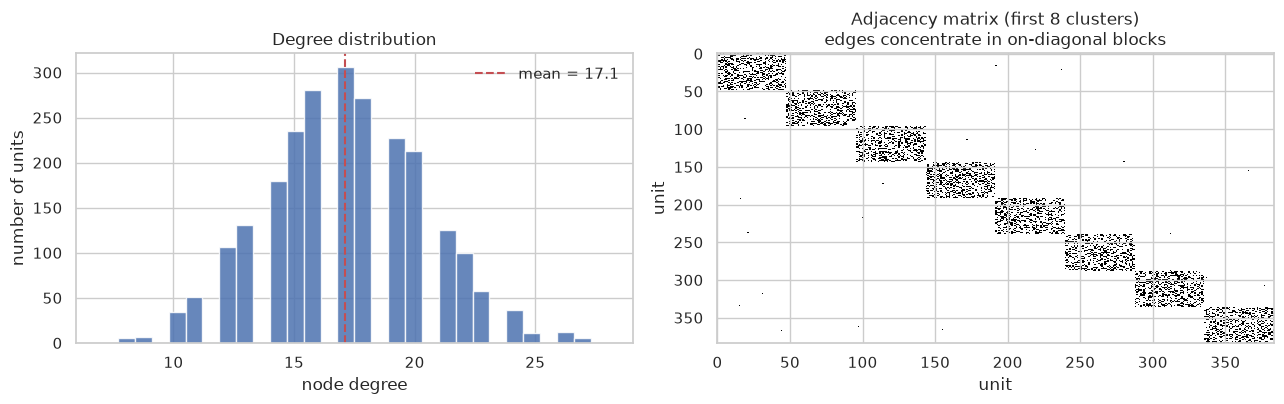

In [4]:
# --- Figure: network structure ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(degree, bins=30, color="#4C72B0", alpha=0.85)
axes[0].axvline(degree.mean(), color="#C44E52", ls="--", label=f"mean = {degree.mean():.1f}")
axes[0].set_xlabel("node degree")
axes[0].set_ylabel("number of units")
axes[0].set_title("Degree distribution")
axes[0].legend(frameon=False)

# adjacency spy on the first 8 clusters, to show the block structure
k = 8 * 48
axes[1].imshow(adj[:k, :k], cmap="Greys", interpolation="nearest", aspect="auto")
axes[1].set_title("Adjacency matrix (first 8 clusters)\nedges concentrate in on-diagonal blocks")
axes[1].set_xlabel("unit")
axes[1].set_ylabel("unit")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/28_network_structure.png", dpi=140, bbox_inches="tight")
plt.show()


## 2. Individual randomization is biased under spillover

Assign each unit independently to treatment or control with probability
0.5 — the standard A/B design — and take the naive difference in means.
Repeated over 400 fresh assignments and outcome draws:


In [5]:
ind = estimate_individual_randomization(
    adj, BASELINE, DIRECT, SPILLOVER, treat_share=0.5, n_simulations=400, random_state=2
)
print(f"mean estimate      : {ind['mean_estimate']:+.4f}")
print(f"true global effect : {GATE:+.4f}")
print(f"direct effect only : {DIRECT:+.4f}")
print(f"bias vs GATE        : {ind['mean_estimate'] - GATE:+.4f}  "
      f"({(ind['mean_estimate'] - GATE) / GATE:+.0%})")


mean estimate      : +0.0389
true global effect : +0.1100
direct effect only : +0.0400
bias vs GATE        : -0.0711  (-65%)


The individually randomized estimate lands on **~0.04 — the direct effect
alone**, throwing away the entire 0.07 spillover component and understating
the true global effect by roughly **two thirds**.

Why: at a 50/50 unit-level split, *every* unit — treated or control — has
about half its neighbours treated. The spillover term is therefore nearly
the same in both arms, so it cancels in the difference and only the direct
term survives. The control group is contaminated by design, and the more
connected the graph, the worse it gets.


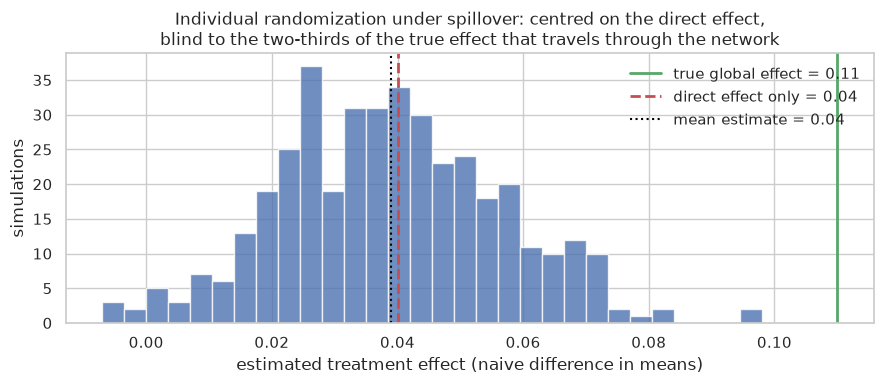

In [6]:
# --- Figure: the individual-randomization sampling distribution ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ind["estimates"], bins=30, color="#4C72B0", alpha=0.8)
ax.axvline(GATE, color="#55A868", lw=2, label=f"true global effect = {GATE:.2f}")
ax.axvline(DIRECT, color="#C44E52", lw=2, ls="--", label=f"direct effect only = {DIRECT:.2f}")
ax.axvline(ind["mean_estimate"], color="black", lw=1.5, ls=":", label=f"mean estimate = {ind['mean_estimate']:.2f}")
ax.set_xlabel("estimated treatment effect (naive difference in means)")
ax.set_ylabel("simulations")
ax.set_title("Individual randomization under spillover: centred on the direct effect,\nblind to the two-thirds of the true effect that travels through the network")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/29_individual_randomization_bias.png", dpi=140, bbox_inches="tight")
plt.show()


## 3. Cluster randomization recovers the global effect — at a variance cost

Randomize **whole clusters** to treatment or control. Now a treated unit
sits in a mostly-treated neighbourhood and a control unit in a
mostly-control one, so the spillover term no longer cancels — the estimate
picks up almost all of `direct + spillover`. Leakage is limited to the
handful of between-cluster edges.

Run it two ways: with clusters that are otherwise identical, and with a
realistic **per-cluster shift** (`cluster_effects`, sd = 6pp) — communities
differ for reasons unrelated to treatment.


In [7]:
rng = np.random.default_rng(99)
cluster_effects = rng.normal(0, 0.06, size=cluster_labels.max() + 1)

clu_homog = estimate_cluster_randomization(
    adj, cluster_labels, BASELINE, DIRECT, SPILLOVER,
    n_simulations=400, cluster_effects=None, random_state=2,
)
clu_heterog = estimate_cluster_randomization(
    adj, cluster_labels, BASELINE, DIRECT, SPILLOVER,
    n_simulations=400, cluster_effects=cluster_effects, random_state=2,
)

tbl = pd.DataFrame({
    "design": ["Individual", "Cluster (identical clusters)", "Cluster (heterogeneous clusters)"],
    "mean estimate": [ind["mean_estimate"], clu_homog["mean_estimate"], clu_heterog["mean_estimate"]],
    "sampling SD": [ind["se_estimate"], clu_homog["se_estimate"], clu_heterog["se_estimate"]],
})
tbl["bias vs GATE"] = tbl["mean estimate"] - GATE
tbl


,design,mean estimate,sampling SD,bias vs GATE
0,Individual,0.038933,0.017566,-0.071067
1,Cluster (identical clusters),0.107163,0.017785,-0.002837
2,Cluster (heterogeneous clusters),0.108022,0.022146,-0.001978


In [8]:
ratio = clu_heterog["se_estimate"] / ind["se_estimate"]
print(f"cluster-design sampling SD is {ratio:.2f}x the individual-design SD "
      f"(with heterogeneous clusters)")
print(f"unit-level SE you'd naively report : {ind['se_estimate']:.4f}  (over-confident)")
print(f"honest cluster-level SE (one run)   : {clu_heterog['cluster_level_se_single_run']:.4f}")


cluster-design sampling SD is 1.26x the individual-design SD (with heterogeneous clusters)
unit-level SE you'd naively report : 0.0176  (over-confident)
honest cluster-level SE (one run)   : 0.0280


Cluster randomization is **near-unbiased for the global effect** (~0.108
vs. 0.11). The costs:

- **Variance.** The effective sample size is the number of *clusters* (50),
  not units (2,400). With heterogeneous clusters the sampling SD is ~1.2x
  the individual design's here — and that multiplier is
  `1 + (m − 1)·ICC` (the *design effect*), so with big clusters or strong
  within-cluster correlation it routinely reaches 5-20x. You need
  materially more total users for the same precision.
- **The SE must be computed at the cluster level.** Treating 2,400 units as
  independent reports an SE that ignores the design and is badly
  over-confident.


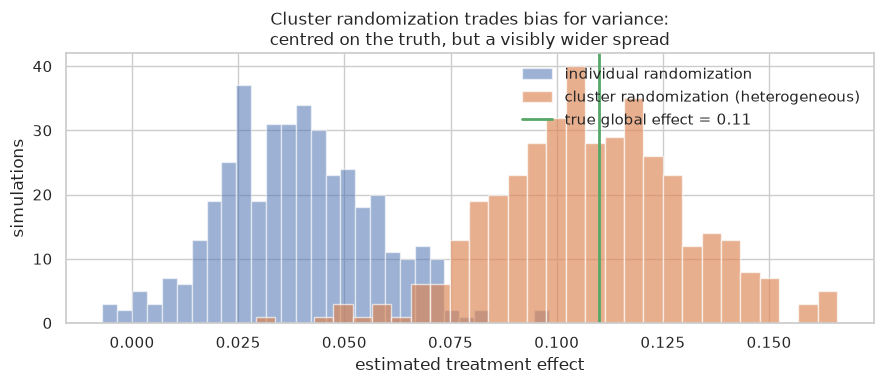

In [9]:
# --- Figure: cluster vs individual sampling distributions ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ind["estimates"], bins=30, color="#4C72B0", alpha=0.55, label="individual randomization")
ax.hist(clu_heterog["estimates"], bins=30, color="#DD8452", alpha=0.65, label="cluster randomization (heterogeneous)")
ax.axvline(GATE, color="#55A868", lw=2, label=f"true global effect = {GATE:.2f}")
ax.set_xlabel("estimated treatment effect")
ax.set_ylabel("simulations")
ax.set_title("Cluster randomization trades bias for variance:\ncentred on the truth, but a visibly wider spread")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/30_cluster_vs_individual.png", dpi=140, bbox_inches="tight")
plt.show()


## 4. Switchback tests for the marketplace case

Sometimes units *can't* be separated: every rider, driver, or bid draws on
one shared pricing / matching pool, so any "control" unit is affected by
the treatment applied to the pool. The fix is to separate treatment and
control **in time** — switch the whole system between arms over successive
blocks of periods.

`simulate_switchback` models the two frictions that make this hard:

1. **Settling / carryover** — the first period after a switch is only
   half-transitioned (`settle_fraction = 0.5`). Short blocks are almost all
   first-periods, so this drags the measured effect toward zero.
   `washout=True` drops the first period of each block — which fixes the
   bias, but is unaffordable when blocks are length 1 (you'd discard
   everything).
2. **Serial correlation** — marketplace state persists (`ar_rho = 0.5`), so
   treating periods as independent *understates* the standard error.

Sweep block length, 480 periods, 400 simulated experiments per setting:


In [10]:
BLOCKS = [1, 2, 4, 8, 24]
rows = []
for bl in BLOCKS:
    for washout in (False, True):
        if washout and bl == 1:
            # washout discards the first period of every block -> with
            # length-1 blocks nothing survives. Record it as not-applicable.
            rows.append({"block_length": bl, "washout": washout,
                         "mean_bias": np.nan, "true_SD": np.nan,
                         "mean_iid_SE": np.nan, "mean_block_SE": np.nan})
            continue
        runs = [
            simulate_switchback(
                n_periods=480, baseline=1.0, period_effect=0.10,
                settle_fraction=0.5, ar_rho=0.5, noise_sd=0.05,
                block_length=bl, washout=washout, random_state=s,
            )
            for s in range(400)
        ]
        biases = np.array([r["carryover_bias"] for r in runs], dtype=float)
        naive = np.array([r["naive_effect"] for r in runs], dtype=float)
        iid = np.array([r["iid_se"] for r in runs], dtype=float)
        blk = np.array([r["block_se"] for r in runs], dtype=float)
        rows.append({
            "block_length": bl, "washout": washout,
            "mean_bias": np.nanmean(biases),
            "true_SD": np.nanstd(naive, ddof=1),
            "mean_iid_SE": np.nanmean(iid),
            "mean_block_SE": np.nanmean(blk),
        })
sw = pd.DataFrame(rows)
sw


,block_length,washout,mean_bias,true_SD,mean_iid_SE,mean_block_SE
0,1,False,-0.050238,0.004771,0.005083,0.005083
1,1,True,NaN,NaN,NaN,NaN
2,2,False,-0.025164,0.005867,0.004969,0.005814
3,2,True,-0.000244,0.006502,0.006429,0.006429
4,4,False,-0.012099,0.006503,0.004817,0.006672
5,4,True,0.000463,0.006971,0.005278,0.007167
6,8,False,-0.006563,0.007567,0.004720,0.007336
7,8,True,-0.000403,0.007847,0.004906,0.007709
8,24,False,-0.001770,0.007836,0.004745,0.007834
9,24,True,0.000362,0.008038,0.004794,0.007976


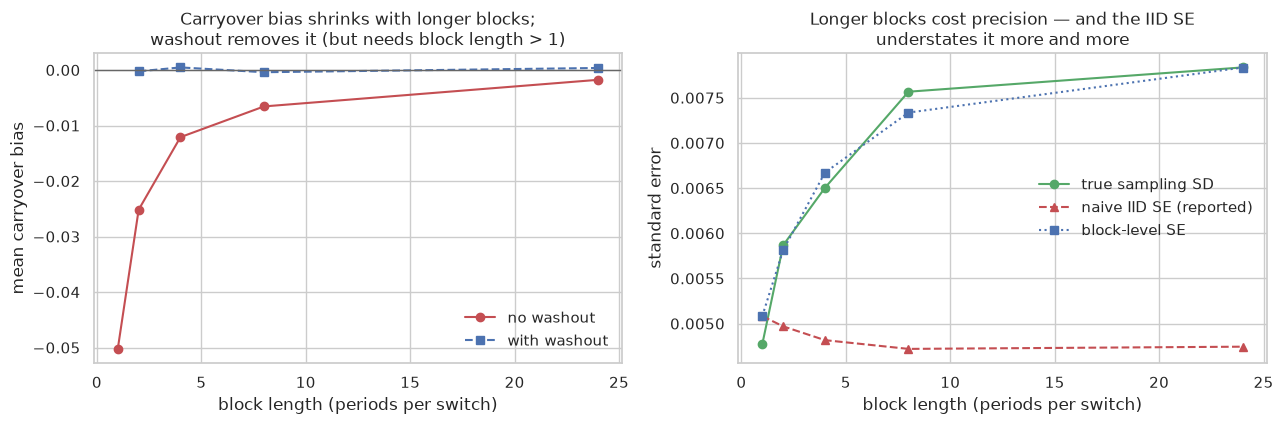

In [11]:
# --- Figure: switchback trade-offs ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

no_w = sw[~sw["washout"]]
w = sw[sw["washout"]]
axes[0].plot(no_w["block_length"], no_w["mean_bias"], "o-", color="#C44E52", label="no washout")
axes[0].plot(w["block_length"], w["mean_bias"], "s--", color="#4C72B0", label="with washout")
axes[0].axhline(0, color="0.4", lw=1)
axes[0].set_xlabel("block length (periods per switch)")
axes[0].set_ylabel("mean carryover bias")
axes[0].set_title("Carryover bias shrinks with longer blocks;\nwashout removes it (but needs block length > 1)")
axes[0].legend(frameon=False)

axes[1].plot(no_w["block_length"], no_w["true_SD"], "o-", color="#55A868", label="true sampling SD")
axes[1].plot(no_w["block_length"], no_w["mean_iid_SE"], "^--", color="#C44E52", label="naive IID SE (reported)")
axes[1].plot(no_w["block_length"], no_w["mean_block_SE"], "s:", color="#4C72B0", label="block-level SE")
axes[1].set_xlabel("block length (periods per switch)")
axes[1].set_ylabel("standard error")
axes[1].set_title("Longer blocks cost precision — and the IID SE\nunderstates it more and more")
axes[1].legend(frameon=False)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/31_switchback_tradeoffs.png", dpi=140, bbox_inches="tight")
plt.show()


Reading the sweep:

- **Block length 1**: carryover bias is ~−50% of the true effect, and you
  can't wash it out. Unusable here.
- **Longer blocks**: bias falls fast (≈ −12% at length 4, ≈ −4% at length
  12), and a one-period washout knocks the residual bias to nearly zero.
- **But** the true sampling SD *grows* with block length — fewer, longer
  blocks means fewer independent randomisation units — and the naive IID
  SE stays flat, so it goes from about right at length 1 to ~35% too small
  at length 12. The block-level SE tracks the truth.
- **The sweet spot** is a block long enough that one washout period is a
  small fraction of it, short enough to keep enough blocks for precision
  and to limit exposure to time-of-day / day-of-week trends.


## 5. Decision guidance

| Symptom | Likely interference | Design fix | Main cost |
|---|---|---|---|
| Treated users influence friends (referrals, feed, messaging); control "leaks up" | Social-graph | **Cluster randomization** at a level that contains most edges (city, school, org) | Effective n = #clusters; design effect `1+(m−1)·ICC` inflates variance; SE must be cluster-level |
| One shared pool (inventory, drivers, ad auction, prices) — control can't be isolated | Marketplace / resource | **Switchback**: alternate the whole system over time blocks (or **cluster by geo/market**) | Carryover between periods; needs washout; fewer effective units; exposed to time trends |
| Effect looks bigger in a small pilot than a full rollout | Saturation-dependent spillover | **Two-stage randomization** (randomise cluster saturation, then units within) | Complex analysis; needs many clusters |

**When it's fine to ignore interference:** weak or no ties between units
(most B2C purchase-conversion tests), very low treatment share (a 1%
holdout barely perturbs the network), or an effect whose mechanism is
purely individual (a checkout-page layout). The Week 4 shared-inventory
result is a caution the other way, though: interference doesn't always
inflate the measured effect — there it *compressed* it — so the safe
assumption is "unknown sign," not "conservative."

**How to detect it before it burns you:**

- Run the test at two treatment saturations (e.g. 10% and 50% of each
  cluster) — if the per-unit effect moves with saturation, spillover is
  real.
- Look for a dose-response in exposure: does a control unit's outcome rise
  with its number of treated neighbours?
- Compare a cluster-randomized and an individually-randomized arm on the
  same feature — a gap between them *is* the spillover.


## What this adds to the toolkit

Weeks 1-6 all assumed SUTVA. This note makes the failure concrete — an
individually randomized test on a connected network recovers only the
direct effect and misses two-thirds of the true impact — and shows the two
standard fixes working on the same simulated data, each with its real
price: cluster randomization pays in variance (the design effect), and
switchback trades unit interference for temporal interference (carryover,
serial correlation). See `writeups/interference_network_effects.md` for the
written version, and Week 4's `simulate_shared_inventory_spillover` for the
worked marketplace-resource example this note builds on.
